<a href="https://colab.research.google.com/github/ruanarth18/Novas-Tecnologias-2026---GPE02N50130/blob/main/Projeto%20Final%20/projeto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final: Análise Exploratória e Modelo Preditivo de Preço de Carros

**Aluno:** Ruan Arthur Rodrigues Gonçalves  
**Contexto:** Este projeto analisa um conjunto de dados de carros usados para entender quais fatores mais influenciam o preço de venda e construir um modelo de regressão capaz de prever o valor de mercado de um carro com base em suas características.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

url = "https://raw.githubusercontent.com/ruanarth18/Novas-Tecnologias-2026---GPE02N50130/main/Projeto%20Final%20/car_data.csv"
df = pd.read_csv(url)
print("Base de dados carregada com sucesso!")
df.head()

Base de dados carregada com sucesso!


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1. Apresentação da Base de Dados, Estatística e Gráficos
Abaixo apresentamos as métricas de média, desvio padrão, mínimos e máximos da base, além dos gráficos que mapeiam as relações visuais entre as variáveis.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       

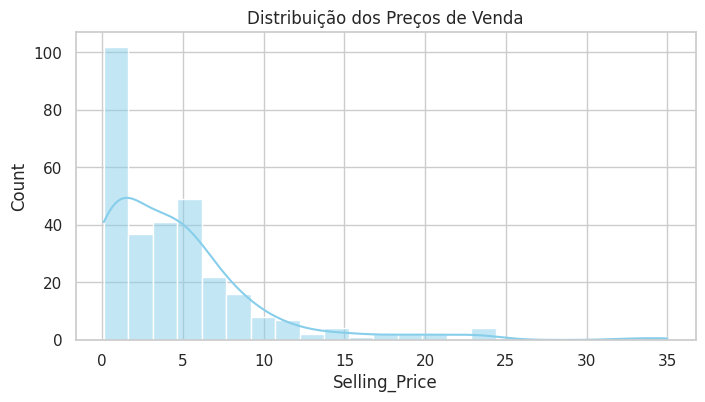

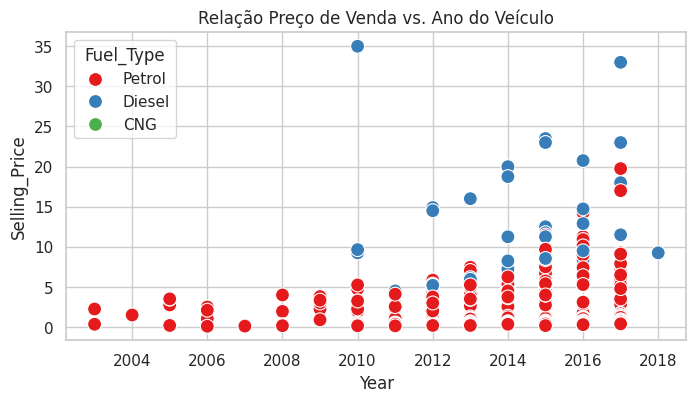

In [ ]:
# Informações gerais das colunas
print(df.info())

# Descrição estatística
print(df.describe())

# Configurar gráficos
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.histplot(df['Selling_Price'], kde=True, color='skyblue')
plt.title('Distribuição dos Preços de Venda')
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Year', y='Selling_Price', hue='Fuel_Type', palette='Set1', s=100)
plt.title('Relação Preço de Venda vs. Ano do Veículo')
plt.show()

## 2. Criação do Modelo de Machine Learning (Regressão)

### Justificativa do Modelo:
Escolhemos o modelo de Regressão Linear. Como o objetivo é prever uma variável contínua (o preço de venda do carro), os modelos de regressão são os recomendados por sua alta interpretabilidade e eficiência.

In [ ]:
# Transformar variáveis categóricas em numéricas
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

# Selecionar variáveis preditoras (X) e a variável alvo (y)
X = df_encoded.drop(columns=['Car_Name', 'Selling_Price'])
y = df_encoded['Selling_Price']

# Separação dos dados em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinamento do Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Previsões e Métricas de Erro
y_pred = modelo.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Métricas de Avaliação:")
print(f"-> Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"-> Coeficiente de Determinação (R²): {r2:.2f}\n")

# Exemplo Prático de Uso do Modelo
novo_carro = pd.DataFrame([{
    'Year': 2016, 'Present_Price': 9.0, 'Kms_Driven': 20000, 'Owner': 0,
    'Fuel_Type_Diesel': False, 'Fuel_Type_Petrol': True, 'Seller_Type_Individual': False, 'Transmission_Manual': True
}])
novo_carro = novo_carro[X_train.columns]
preco_previsto = modelo.predict(novo_carro)[0]
print(f"📊 EXEMPLO DE USO - Preço de venda estimado para o carro fictício: {preco_previsto:.2f}")

Métricas de Avaliação:
-> Erro Médio Absoluto (MAE): 1.22
-> Coeficiente de Determinação (R²): 0.85

📊 EXEMPLO DE USO - Preço de venda estimado para o carro fictício: 6.15
